# General

In [1]:
import h5py
import numpy as np
from h5py.h5r import Reference
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, NullLocator
import matplotlib as mpl


class Struct:
    def __init__(self, fields):
        for k, v in fields.items():
            setattr(self, k, v)

def load_res(path):
    with h5py.File(path, "r") as f:
        ds = f["res"]
        rec = ds[()]

        fields = {}

        for name in rec.dtype.names:
            field = rec[name]

            if isinstance(field, Reference):      # HDF5 reference
                obj = f[field][()]
                fields[name] = obj
            elif isinstance(field, np.ndarray) and field.shape == ():
                fields[name] = field.item()
            else:
                fields[name] = field

    return Struct(fields)

# Data:

## $D_{fm}$

In [2]:
L_list_dim = [28, 32, 36, 40, 44, 52, 60, 68, 76, 80, 84, 88, 92, 96, 100, 104, 110, 114, 118, 124, 134, 144, 154, 158, 162]
for L in L_list_dim:
    fname = f"Data-dimer/L{L}-S10000.jld2"
    res = load_res(fname)
    for key, value in vars(res).items():
        globals()[f"{key}_{L}_dim"] = value;

## $C_{EA}$

In [3]:
L_list_EA = [28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 80, 84, 88, 92, 96, 100, 104, 110, 114, 118, 124, 134, 144, 154, 158, 162]
for L in L_list_EA:
    fname = f"Data-C-EA/L{L}-s10000.jld2"
    res = load_res(fname)
    for key, value in vars(res).items():
        globals()[f"{key}_{L}_EA"] = value;

# Fig.1(a) - Manuscript

Saved high-quality PDF as: Figs/1d-majorana-EA-FM.pdf


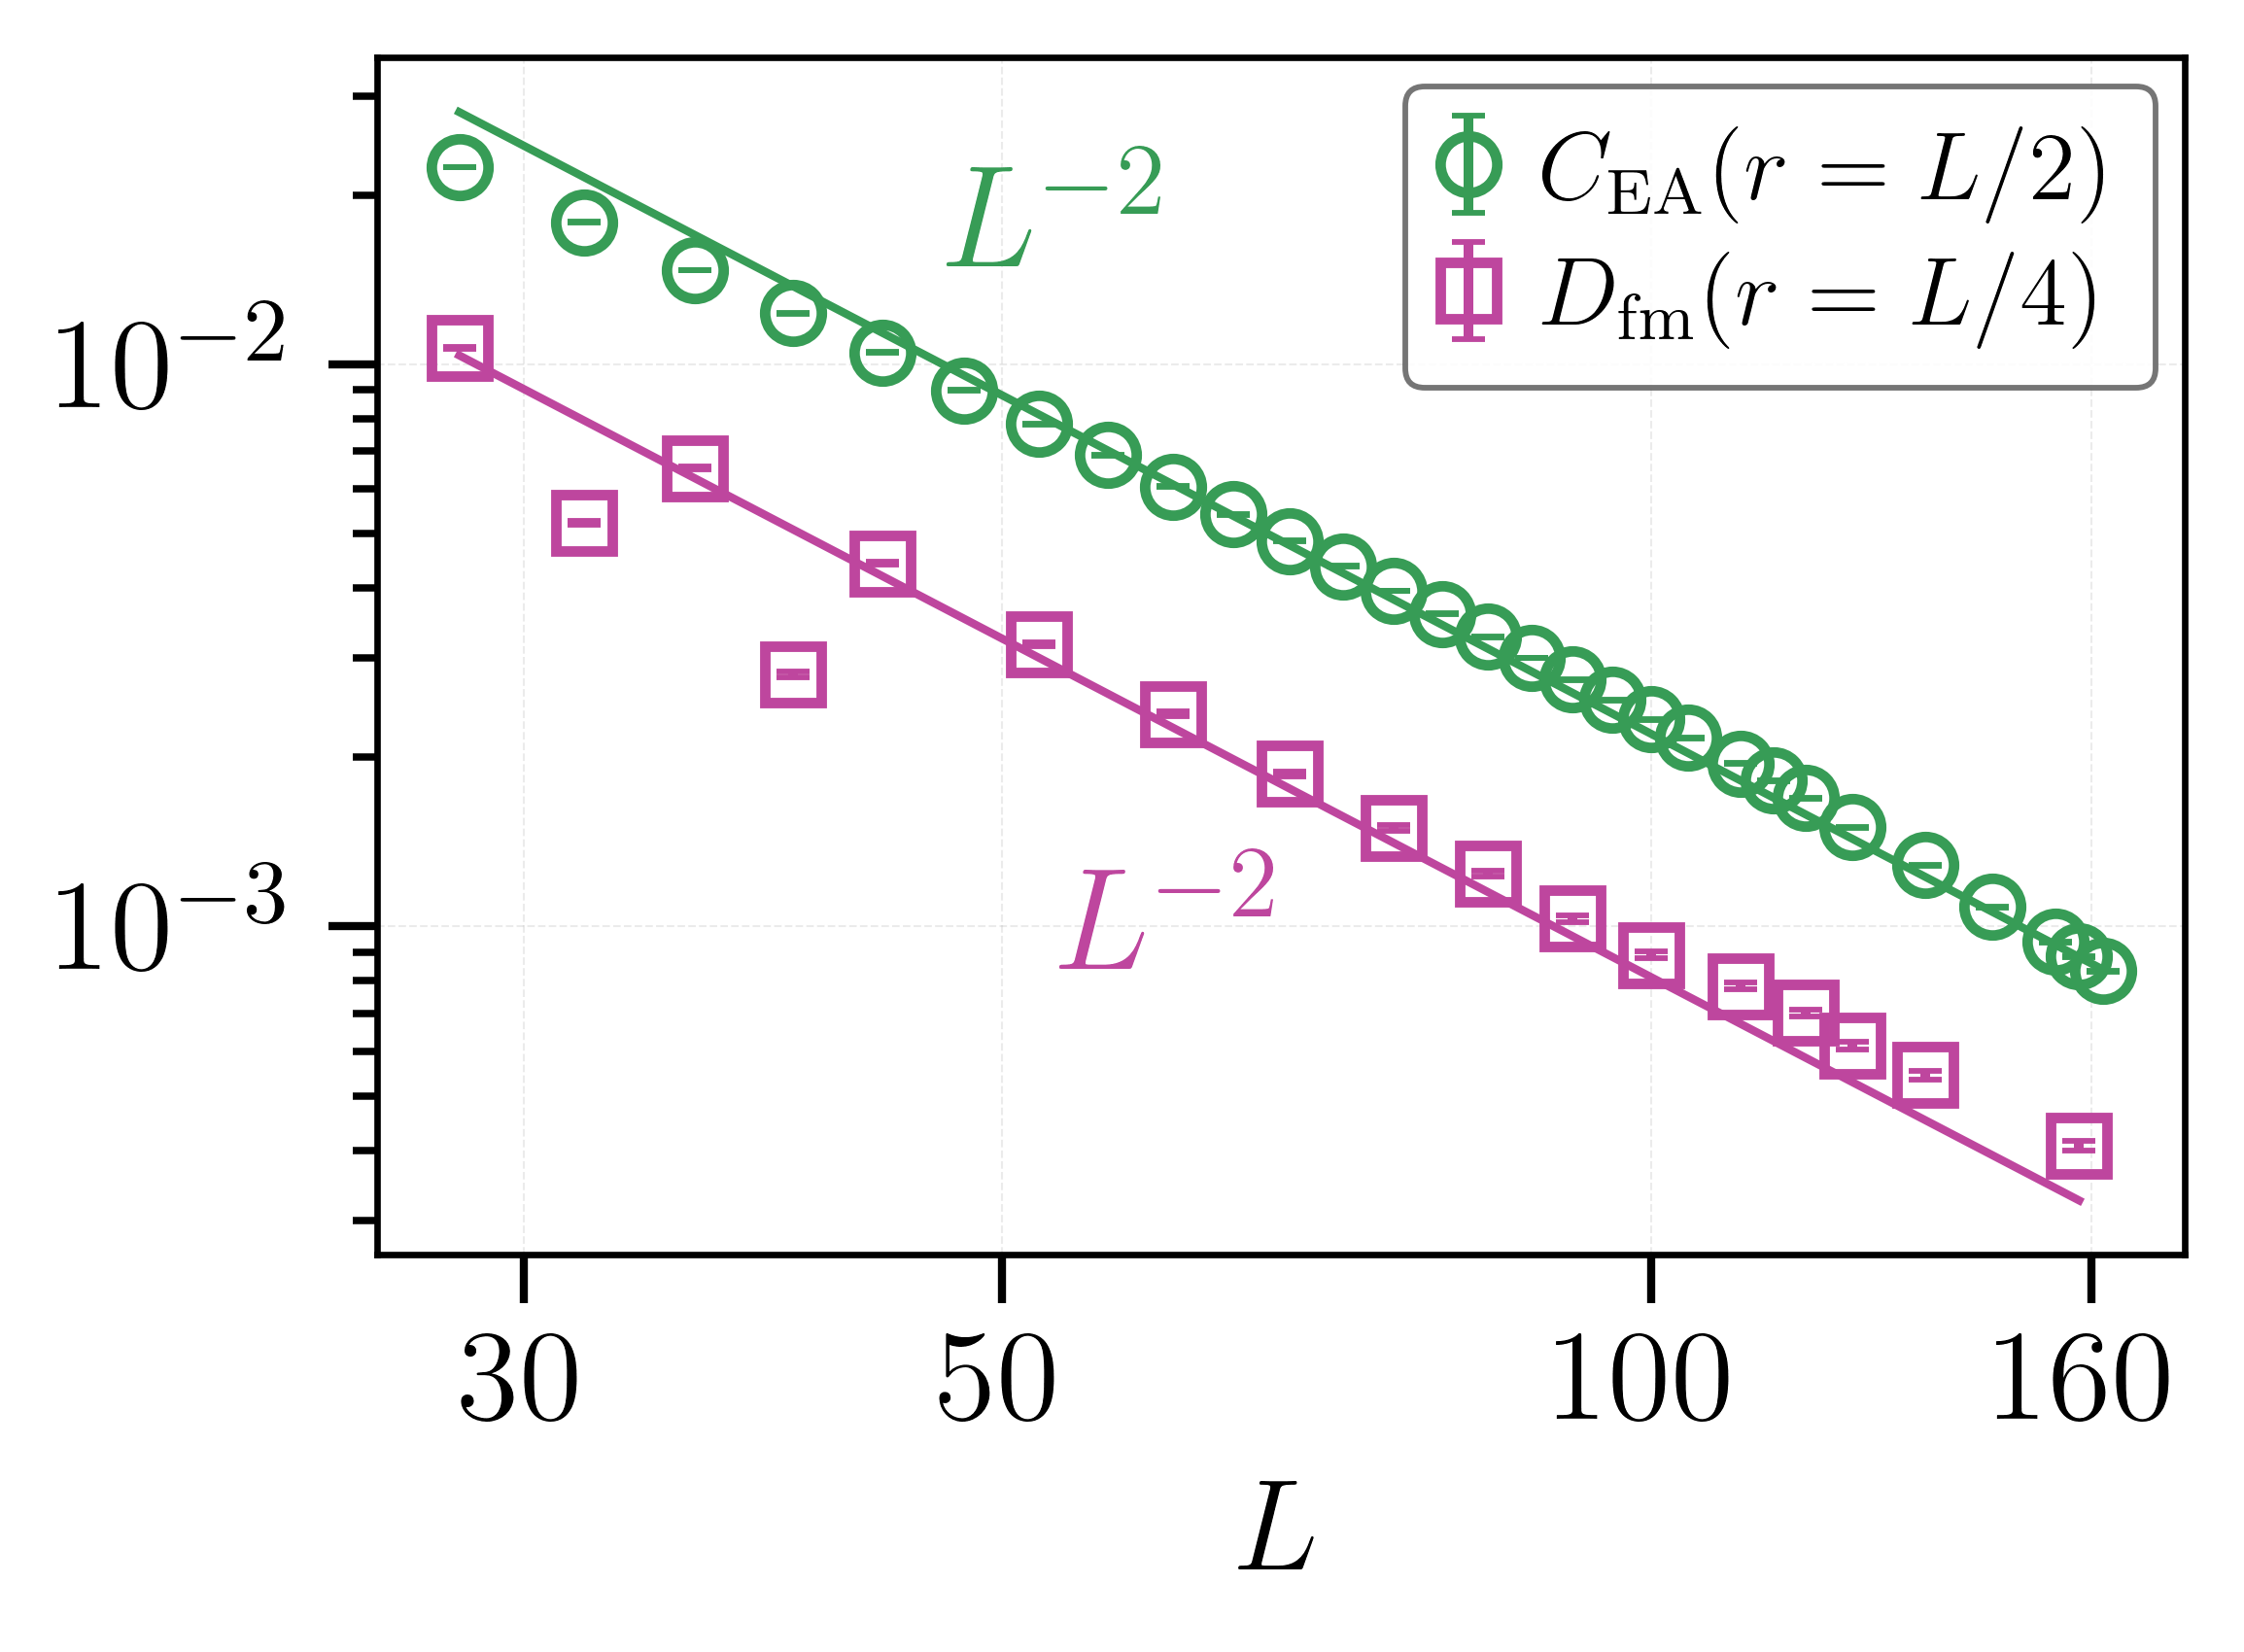

In [5]:
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 12
LABEL_FSIZE  = 16
TICK_FSIZE   = 16
ANNOT_FSIZE  = 18

# ------------
# Parameters 
# ------------
R_MIN = 3
SNR_MIN_CEA = 10
SNR_MIN_DFM = 10

# ---------------
# Colors
# ---------------
 
ce_color  = '#379c56ff'   # C_EA
dfm_color = '#be469eff'    # D_fm

def fit_A_fixed_m_minus2(L, y, yerr=None):
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.any(y <= 0):
        raise ValueError("All y must be positive to fit in log-space.")

    logA_samples = np.log(y) + 2.0 * np.log(L)

    if yerr is None:
        logA = np.mean(logA_samples)
    else:
        yerr = np.asarray(yerr, dtype=float)
        snr = y / yerr
        w = snr**2
        w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
        logA = np.sum(w * logA_samples) / np.sum(w) if np.sum(w) > 0 else np.mean(logA_samples)

    return float(np.exp(logA))

def place_scaling_label_near_line(ax, A, Lmin, Lmax, frac, y_mult, color,
                                 text=r'$L^{-2}$', fontsize=ANNOT_FSIZE):
    L0 = float(np.exp(np.log(Lmin) + frac * (np.log(Lmax) - np.log(Lmin))))
    y0 = float(A * L0**(-2))

    ax.text(
        L0, y0 * y_mult,
        text,
        fontsize=fontsize,
        color=color,
        ha='left', va='center',
        zorder=6,
    )

# -------------------
# Figure / axes
# -------------------
fig, ax = plt.subplots(figsize=(4,8/3), dpi=600)

# =====================
# 0) Positivity pass 
# =====================
for L in L_list_EA:
    for base in ["G2_abs"]:
        y = np.asarray(globals()[f"{base}_{L}_EA"], dtype=float)
        e = np.asarray(globals()[f"{base}_err_{L}_EA"], dtype=float)
        keep = np.isfinite(y) & np.isfinite(e) & (y > 0) & (e > 0)
        y2, e2 = y.copy(), e.copy()
        y2[~keep] = np.nan
        e2[~keep] = np.nan
        globals()[f"{base}_{L}_EA"] = y2
        globals()[f"{base}_err_{L}_EA"] = e2

for L in L_list_dim:
    for base in ["C_DC_stag"]:
        y = np.asarray(globals()[f"{base}_{L}_dim"], dtype=float)
        e = np.asarray(globals()[f"{base}_err_{L}_dim"], dtype=float)
        keep = np.isfinite(y) & np.isfinite(e) & (y > 0) & (e > 0)
        y2, e2 = y.copy(), e.copy()
        y2[~keep] = np.nan
        e2[~keep] = np.nan
        globals()[f"{base}_{L}_dim"] = y2
        globals()[f"{base}_err_{L}_dim"] = e2

# =======================
# 1) C_EA(r = L/2)
# =======================
c_val_cea = 0.50
Ls, vals, errs, rs = [], [], [], []

for L in L_list_EA:
    r_float = c_val_cea * L
    r = int(np.round(r_float))
    if r % 2 == 0:
        r = r + 1 if r_float >= r else r - 1
    if r < R_MIN:
        continue

    idx = r - 1
    y = globals()[f"G2_abs_{L}_EA"][idx]
    e = globals()[f"G2_abs_err_{L}_EA"][idx]
    if not np.isfinite(y) or not np.isfinite(e):
        continue

    Ls.append(L); vals.append(y); errs.append(e); rs.append(r)

Ls, vals, errs, rs = map(np.asarray, (Ls, vals, errs, rs))
mask = (vals / errs >= SNR_MIN_CEA) & (rs >= R_MIN)

L_f, y_f, e_f = Ls[mask], vals[mask], errs[mask]

eb = ax.errorbar(
    L_f, y_f, yerr=e_f,
    fmt='o', color=ce_color, ecolor=ce_color,
    markersize=7, markerfacecolor='none',
    capsize=2, elinewidth=1.2, capthick=0.7,
    label=r'$C_{\mathrm{EA}}(r=L/2)$',
    zorder=3
)
eb[0].set_markeredgewidth(1.3)

A_cea = fit_A_fixed_m_minus2(L_f, y_f, yerr=e_f)
L_fit = np.linspace(L_f.min(), L_f.max(), 300)
ax.plot(L_fit, A_cea * L_fit**(-2), color=ce_color, lw=1.0)

# =====================
# 2) D_fm(r = L/4)
# =====================
c_val_dfm = 0.25
Ls, vals, errs = [], [], []

for L in L_list_dim:
    r = int(np.floor(c_val_dfm * L))
    if r < R_MIN:
        continue

    idx = r - 1
    y = globals()[f"C_DC_stag_{L}_dim"][idx]
    e = globals()[f"C_DC_stag_err_{L}_dim"][idx]
    if not np.isfinite(y) or not np.isfinite(e):
        continue

    Ls.append(L); vals.append(y); errs.append(e)

Ls, vals, errs = map(np.asarray, (Ls, vals, errs))
mask = (vals / errs >= SNR_MIN_DFM)

L_f, y_f, e_f = Ls[mask], vals[mask], errs[mask]

eb = ax.errorbar(
    L_f, y_f, yerr=e_f,
    fmt='s', color=dfm_color, ecolor=dfm_color,
    markersize=7, markerfacecolor='none',
    capsize=2, elinewidth=1.2, capthick=0.7,
    label=r'$D_{\mathrm{fm}}(r=L/4)$',
    zorder=3
)
eb[0].set_markeredgewidth(1.3)

A_dfm = fit_A_fixed_m_minus2(L_f, y_f, yerr=e_f)
L_fit = np.linspace(L_f.min(), L_f.max(), 300)
ax.plot(L_fit, A_dfm * L_fit**(-2), color=dfm_color, lw=1.0)

# --------------------
# Annotations
# --------------------
place_scaling_label_near_line(ax, A_cea, L_f.min(), L_f.max(),
                              frac=0.30, y_mult=1.75,
                              color=ce_color, text=r'$L^{-2}$')
place_scaling_label_near_line(ax, A_dfm, L_f.min(), L_f.max(),
                              frac=0.37, y_mult=0.34,
                              color=dfm_color, text=r'$L^{-2}$')

# ----------------------------
# Axes + legend formatting
# ----------------------------
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$L$', fontsize=LABEL_FSIZE)

L_ticks = [30, 50, 100, 160]
ax.set_xticks(L_ticks)
ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
ax.xaxis.set_minor_locator(NullLocator())

ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
ax.tick_params(axis='both', which='minor', labelsize=TICK_FSIZE, length=3, width=0.9)


leg = ax.legend(
    fontsize=LEGEND_FONTSIZE,
    loc='upper right',
    handlelength=0.5,
    handletextpad=0.5,
    borderpad=0.4,
    labelspacing=0.3,
    borderaxespad=0.3,
    frameon=True,
)
frame = leg.get_frame()
frame.set_edgecolor('0.4')   # medium gray
frame.set_linewidth(0.7)
frame.set_facecolor('white')
frame.set_alpha(0.9)


pdf_name = "Figs/1d-majorana-EA-FM.pdf"

plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08,
    transparent=False
)
print(f"Saved high-quality PDF as: {pdf_name}")
plt.show()

# Fig.4(a) - Supplemental Material

Saved high-quality PDF as: Figs/1d-majorana-D-sc.pdf


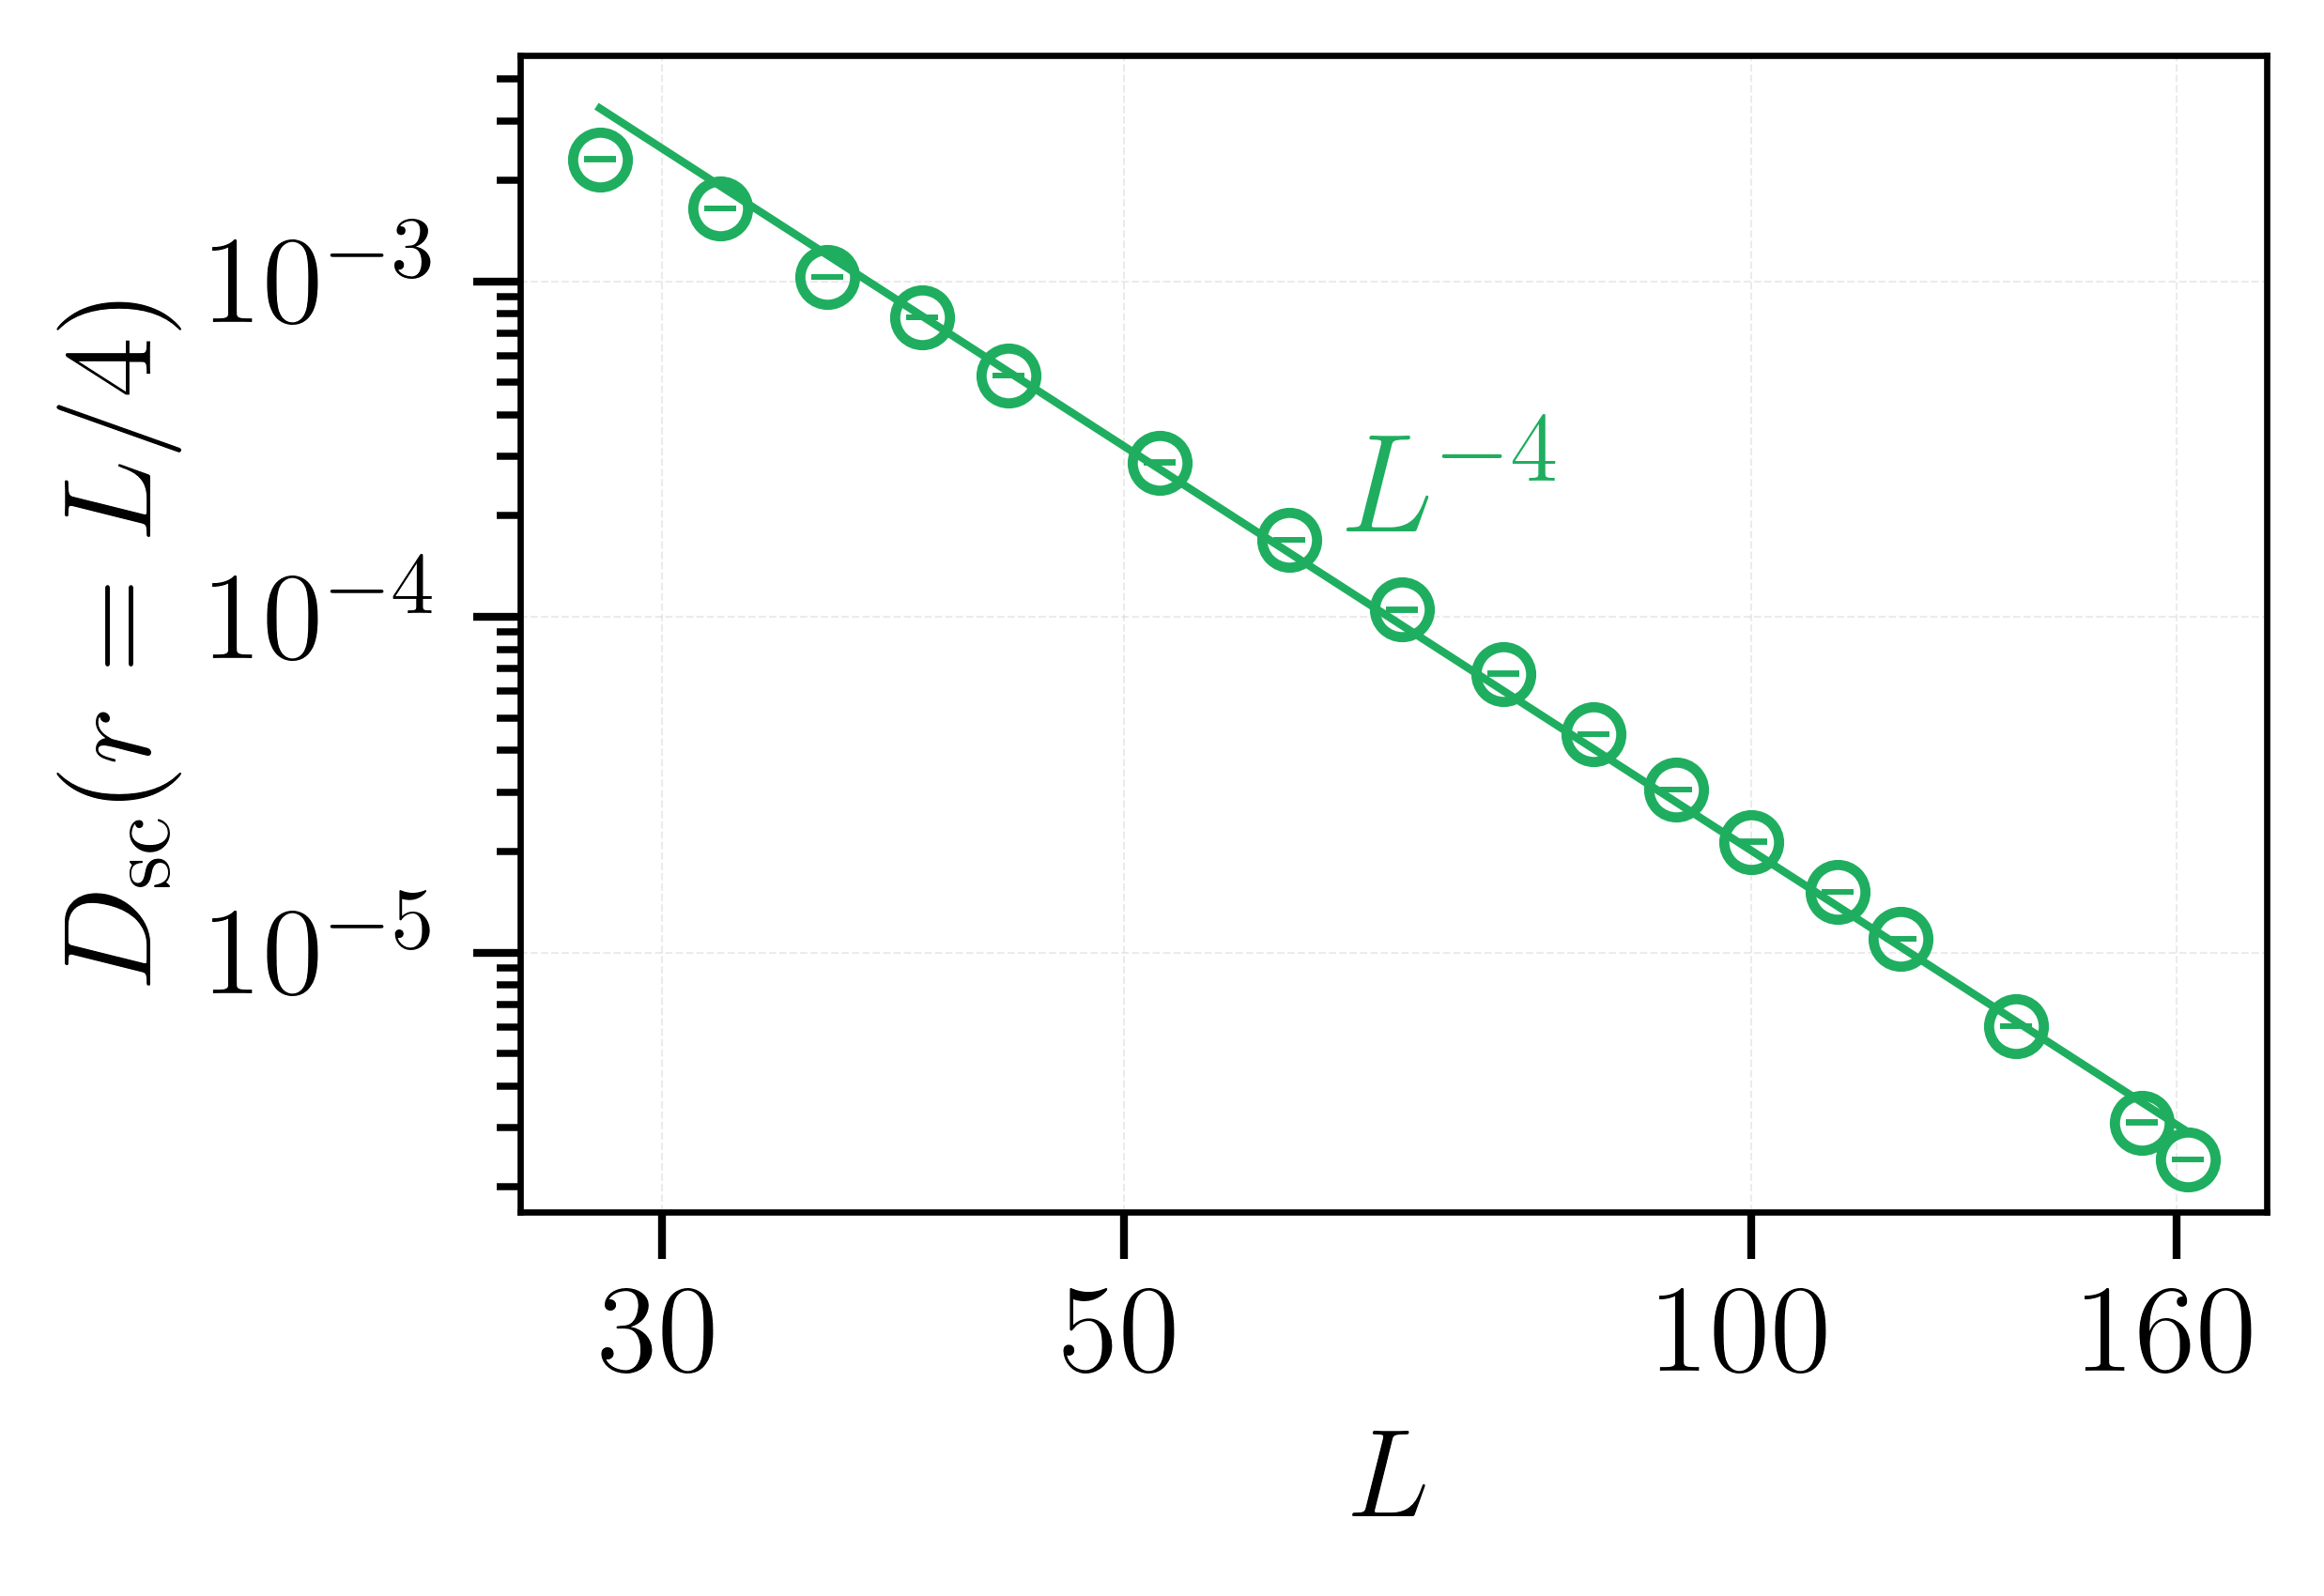

In [6]:
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 13
LABEL_FSIZE  = 16
TICK_FSIZE   = 16
ANNOT_FSIZE  = 18

# ---------------
# Parameters
# ---------------
R_MIN = 3
SNR_MIN_DSC = 3    
c_val_dsc   = 0.25    # r = L/4

# (1.0 = pure fit)
A_MULT = 1.0

SPARSITY_RULES = [
    (0,   70,  1),
    (72,  172, 2),
]

dsc_color =  "#1FAE5F"

def fit_A_fixed_m_minus4(L, y, yerr=None):
    """
    Fit amplitude A in y ~ A * L^{-4} in log-space:
      log A = log y + 4 log L
    Weighted by snr^2 if yerr is provided.
    """
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.any(y <= 0):
        raise ValueError("All y must be positive to fit in log-space.")

    logA_samples = np.log(y) + 4.0 * np.log(L)

    if yerr is None:
        logA = np.mean(logA_samples)
    else:
        yerr = np.asarray(yerr, dtype=float)
        snr = y / yerr
        w = snr**2
        w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
        logA = np.sum(w * logA_samples) / np.sum(w) if np.sum(w) > 0 else np.mean(logA_samples)

    return float(np.exp(logA))

def place_scaling_label_near_line(ax, A, Lmin, Lmax, frac, y_mult, color,
                                 text=r'$L^{-4}$', fontsize=ANNOT_FSIZE):
    L0 = float(np.exp(np.log(Lmin) + frac * (np.log(Lmax) - np.log(Lmin))))
    y0 = float(A * L0**(-4))
    ax.text(
        L0, y0 * y_mult,
        text,
        fontsize=fontsize,
        color=color,
        ha='left', va='center',
        zorder=6,
    )

def sparsify_by_L_rules(L, *arrays, rules=SPARSITY_RULES):
    """
    Given L and aligned arrays, keep every k-th point within L bins
    defined by `rules` = [(Lmin, Lmax, k), ...].
    Points are first sorted by L.
    """
    L = np.asarray(L)
    order = np.argsort(L)
    Ls = L[order]
    arrs = [np.asarray(a)[order] for a in arrays]

    keep_mask = np.zeros_like(Ls, dtype=bool)

    for (Lmin, Lmax, k) in rules:
        in_bin = (Ls >= Lmin) & (Ls <= Lmax)
        idxs = np.where(in_bin)[0]
        if idxs.size == 0:
            continue
        if k <= 1:
            keep_mask[idxs] = True
        else:
            # keep every k-th inside this bin (relative indexing)
            keep_mask[idxs[::k]] = True

    L_out = Ls[keep_mask]
    outs = [a[keep_mask] for a in arrs]
    return (L_out, *outs)

# -------------------
# Figure / axes
# -------------------
fig, ax = plt.subplots(figsize=(4, 8/3), dpi=600)

# ======================
# 0) Positivity pass
# ======================
for L in L_list_dim:
    base = "C_SC_stag"
    y = np.asarray(globals()[f"{base}_{L}_dim"], dtype=float)
    e = np.asarray(globals()[f"{base}_err_{L}_dim"], dtype=float)
    keep = np.isfinite(y) & np.isfinite(e) & (y > 0) & (e > 0)
    y2, e2 = y.copy(), e.copy()
    y2[~keep] = np.nan
    e2[~keep] = np.nan
    globals()[f"{base}_{L}"] = y2
    globals()[f"{base}_err_{L}"] = e2

# ====================================
# 1) Collect D_sc(r = L/4) points
# ====================================
Ls, vals, errs = [], [], []

for L in L_list_dim:
    r = int(np.floor(c_val_dsc * L))   # r = floor(L/4)
    if r < R_MIN:
        continue

    idx = r - 1
    y = globals()[f"C_SC_stag_{L}_dim"][idx]
    e = globals()[f"C_SC_stag_err_{L}_dim"][idx]
    if not np.isfinite(y) or not np.isfinite(e):
        continue

    Ls.append(L); vals.append(y); errs.append(e)

Ls, vals, errs = map(np.asarray, (Ls, vals, errs))
mask = (vals / errs >= SNR_MIN_DSC)

L_f, y_f, e_f = Ls[mask], vals[mask], errs[mask]

L_plot, y_plot, e_plot = sparsify_by_L_rules(L_f, y_f, e_f, rules=SPARSITY_RULES)

# ========================
# 3) Plot points
# ========================
eb = ax.errorbar(
    L_plot, y_plot, yerr=e_plot,
    fmt='o', color=dsc_color, ecolor=dsc_color,
    markersize=7, markerfacecolor='none',
    capsize=2, elinewidth=1.2, capthick=0.7,
    #label=r'$D_{\mathrm{sc}}(r=L/4)$',
    zorder=3
)
eb[0].set_markeredgewidth(1.3)

# =======================
# 4) L^{-4} fit line 
# =======================
A_dsc = fit_A_fixed_m_minus4(L_f, y_f, yerr=e_f) * A_MULT
L_fit = np.linspace(L_f.min(), L_f.max(), 300)
ax.plot(L_fit, A_dsc * L_fit**(-4), color=dsc_color, lw=1.0)

place_scaling_label_near_line(
    ax, A_dsc, L_f.min(), L_f.max(),
    frac=0.47, y_mult=1.9,
    color=dsc_color, text=r'$L^{-4}$'
)

# ------------------------------
# Axes + legend formatting
# ------------------------------
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$L$', fontsize=LABEL_FSIZE)
ax.set_ylabel(r'$D_{\mathrm{sc}}(r=L/4)$', fontsize=LABEL_FSIZE)

L_ticks = [30, 50, 100, 160]
ax.set_xticks(L_ticks)
ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
ax.xaxis.set_minor_locator(NullLocator())

ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
ax.tick_params(axis='both', which='minor', labelsize=TICK_FSIZE, length=3, width=0.9)

pdf_name = "Figs/1d-majorana-D-sc.pdf"

plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08,
    transparent=False
)
print(f"Saved high-quality PDF as: {pdf_name}")
plt.show()